# scikit-learn „Getting Started“ – **Dozentenversion**

**Quelle:** Dieses Notebook ist didaktisch auf Basis der offiziellen scikit-learn-Seite  
**„Getting Started“** aufgebaut und für eine Bachelor-Vorlesung vereinfacht, strukturiert und um Fragen sowie kleine Übungen ergänzt.

## Ziel dieses Notebooks
Nach der Bearbeitung sollten Studierende:

- den Grundaufbau eines scikit-learn-Workflows verstehen,
- den Unterschied zwischen **Estimator**, **Transformer** und **Pipeline** erklären können,
- ein Modell mit `fit()` trainieren und mit `predict()` Vorhersagen berechnen können,
- die Grundidee von **Train/Test-Split** und **Cross-Validation** verstehen,
- typische Fehler wie **Data Leakage** vermeiden.

## 0. Vorbereitung

Wir importieren zunächst die wichtigsten Bibliotheken. Nicht jede davon wird sofort benötigt; einige kommen erst in späteren Abschnitten zum Einsatz.


In [ ]:

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris, make_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("Imports erfolgreich geladen.")


Imports erfolgreich geladen.


## 1. Estimator-Grundlagen: `fit()` und `predict()`

In scikit-learn heißen lernbare Modelle **Estimatoren**.  
Ein Estimator ist ein Objekt, das aus Daten eine Regel lernt.

Die Standardlogik lautet fast immer:

1. Modell erzeugen  
2. Modell mit `fit(X, y)` trainieren  
3. Mit `predict(X_neu)` Vorhersagen berechnen  

### Wichtige Begriffe
- `X`: Eingabedaten, meist eine Matrix mit Form `(n_samples, n_features)`
- `y`: Zielvariable, also die richtige Antwort
- `fit()`: Training des Modells
- `predict()`: Vorhersage für bekannte oder neue Daten

Im folgenden Mini-Beispiel verwenden wir einen `RandomForestClassifier`.

> **Wichtig:** Dieses Mini-Beispiel dient vor allem dazu, die API mit `fit()` und `predict()` zu verstehen.  
> Es ist bewusst klein gewählt und kein realistisches Trainingsszenario.



In [ ]:

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=0)

# 2 Beobachtungen, 3 Merkmale
X = [[1, 2, 3],
     [11, 12, 13]]

# Klassenzugehörigkeit der beiden Beobachtungen
y = [0, 1]

clf.fit(X, y)

print("Vorhersagen für die Trainingsdaten:", clf.predict(X))
print("Vorhersagen für neue Daten:", clf.predict([[4, 5, 6], [14, 15, 16]]))


Vorhersagen für die Trainingsdaten: [0 1]
Vorhersagen für neue Daten: [0 1]


### Verständnisfragen
1. Was ist der Unterschied zwischen `X` und `y`?
2. Was macht die Methode `fit()`?
3. Warum ist `predict()` erst nach `fit()` sinnvoll?

### Muster-Antworten


### Mini-Übung
Ändere im Beispiel die neuen Eingabedaten und beobachte, wie sich die Vorhersagen ändern.


In [ ]:

# Übung 1:
# Ersetze die beiden neuen Datenpunkte durch eigene Werte und führe die Zelle aus.

neue_daten = [
    [2, 3, 4],
    [20, 21, 22]
]

print(clf.predict(neue_daten))


[0 1]


## 2. Transformer und Vorverarbeitung

Viele ML-Workflows bestehen nicht nur aus einem Modell, sondern auch aus einer **Vorverarbeitung**.

Beispiel:
- Merkmale skalieren
- fehlende Werte ersetzen
- Text in Zahlen umwandeln

Objekte für solche Schritte heißen in scikit-learn oft **Transformer**.

Ein Transformer hat typischerweise:
- `fit()`: lernt z. B. Mittelwert und Standardabweichung
- `transform()`: wendet die Transformation auf Daten an

Ein klassisches Beispiel ist der `StandardScaler`.
Er verschiebt die Merkmale auf Mittelwert 0 und skaliert sie auf vergleichbare Größenordnungen.


In [ ]:
from sklearn.preprocessing import StandardScaler

X = [[0, 15],
     [1, -10]]

scaler = StandardScaler()
X_scaled = scaler.fit(X).transform(X)

print("Originaldaten:")
print(np.array(X))

print("\nSkalierte Daten:")
print(X_scaled)

Originaldaten:
[[  0  15]
 [  1 -10]]

Skalierte Daten:
[[-1.  1.]
 [ 1. -1.]]


### Visualisierung: Skalierung im Vergleich

Der folgende Plot zeigt zwei Merkmale des Iris-Datensatzes **vor** und **nach** der Standardisierung. Man erkennt gut, dass die Skala der Achsen sich verändert, die relative Struktur der Daten aber erhalten bleibt.


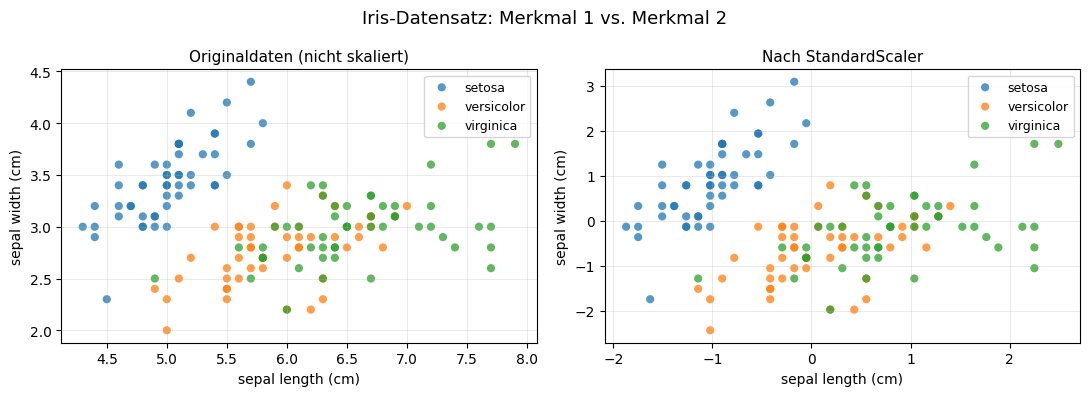

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import numpy as np

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names

scaler_vis = StandardScaler()
X_iris_scaled = scaler_vis.fit_transform(X_iris)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
labels = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Iris-Datensatz: Merkmal 1 vs. Merkmal 2", fontsize=13, fontweight="normal")

for ax, X_plot, title in zip(
    axes,
    [X_iris, X_iris_scaled],
    ["Originaldaten (nicht skaliert)", "Nach StandardScaler"]
):
    for cls in range(3):
        mask = y_iris == cls
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   color=colors[cls], label=labels[cls], alpha=0.75, s=35, edgecolors="none")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.legend(fontsize=9)
    ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()


### Warum ist Skalierung wichtig?

Manche Verfahren reagieren empfindlich auf unterschiedliche Größenordnungen der Merkmale.  
Das ist zum Beispiel häufig bei:
- logistischer Regression,
- k-NN,
- SVM,
- neuronalen Netzen

wichtig.

Nicht jedes Modell profitiert gleich stark von Skalierung.  
Baumverfahren wie Entscheidungsbäume oder Random Forests sind meist deutlich weniger empfindlich gegenüber der Skala der Merkmale.

### Verständnisfragen
1. Was lernt der `StandardScaler` beim `fit()`?
2. Warum kann Vorverarbeitung die Modellqualität verbessern?
3. Ist ein `Transformer` selbst schon ein Vorhersagemodell?

### Muster-Antworten


### Mini-Übung
Ändere die Werte in `X` so, dass ein Merkmal viel größere Zahlen enthält als das andere. Vergleiche dann die skalierten Werte.

In [ ]:
# Übung 2:
# Probiere eigene Werte aus und beobachte den Effekt der Skalierung.

X_test = [[100, 1],
          [200, 2],
          [300, 3]]

scaler = StandardScaler()
print(scaler.fit_transform(X_test))


[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


## 3. Pipelines: Vorverarbeitung und Modell sauber verketten

Ein sehr wichtiger Baustein in scikit-learn ist die **Pipeline**.

Eine Pipeline verbindet mehrere Schritte zu einem einzigen Workflow, zum Beispiel:

**Skalierung -> Klassifikationsmodell**

Vorteile:
- klarer und sauberer Code,
- weniger Fehler,
- gleiche API wie bei einem normalen Modell,
- Schutz vor **Data Leakage**, wenn korrekt mit Train/Test-Split oder Cross-Validation gearbeitet wird.

Im Beispiel kombinieren wir:
- `StandardScaler()`
- `LogisticRegression()`


In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0, stratify=y
)

pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Accuracy auf dem Testset:", accuracy_score(y_test, y_pred))

Accuracy auf dem Testset: 0.9736842105263158


### Visualisierung: Konfusionsmatrix

Die Konfusionsmatrix zeigt, welche Klassen das Modell korrekt klassifiziert und wo es Fehler macht. Jede Zeile entspricht der wahren Klasse, jede Spalte der vorhergesagten Klasse.


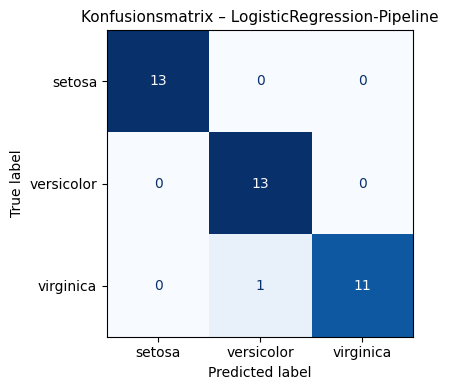

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=load_iris().target_names)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Konfusionsmatrix – LogisticRegression-Pipeline", fontsize=11)
plt.tight_layout()
plt.show()


### Warum ist die Pipeline didaktisch und praktisch wichtig?

Die Pipeline sorgt dafür, dass die Vorverarbeitung **nur auf Basis der Trainingsdaten gelernt** wird.  
Genau das ist zentral, damit wir die Testdaten nicht unzulässig „mitschneiden“.

Das ist ein typischer Fehler in Einsteigerprojekten.

### Verständnisfragen
1. Welche zwei Schritte enthält die Pipeline im Beispiel?
2. Warum ist eine Pipeline oft besser als einzelne manuelle Schritte?
3. Was bedeutet **Data Leakage** in diesem Zusammenhang?

### Muster-Antworten


### Mini-Übung
Ersetze `LogisticRegression()` durch ein anderes Modell, das von Skalierung profitieren kann, zum Beispiel `KNeighborsClassifier()`.

In [ ]:
# Übung 3:
# Tausche das Modell in der Pipeline aus.
# Beispielidee: KNeighborsClassifier()

from sklearn.neighbors import KNeighborsClassifier

pipe2 = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

pipe2.fit(X_train, y_train)
print("Accuracy der alternativen Pipeline:", accuracy_score(y_test, pipe2.predict(X_test)))

Accuracy der alternativen Pipeline: 0.9736842105263158


## 4. Modellevaluation

Ein Modell ist nicht gut, nur weil es auf den Trainingsdaten gute Ergebnisse liefert.

Entscheidend ist die Frage:

> **Wie gut funktioniert das Modell auf bisher ungesehenen Daten?**

Dafür nutzen wir Evaluationsmethoden.  
Eine einfache Variante ist der **Train/Test-Split**.  
Noch robuster ist oft die **Cross-Validation**.

Bei der Cross-Validation wird das Dataset mehrfach in Trainings- und Testteile zerlegt.  
So erhält man eine stabilere Einschätzung der Modellleistung.

In diesem Abschnitt bleiben wir bei einer **Klassifikationsaufgabe mit dem Iris-Datensatz**, damit der rote Faden konsistent bleibt.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

X, y = load_iris(return_X_y=True)

pipe_cv = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

result = cross_validate(
    pipe_cv,
    X,
    y,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

print("Schlüssel im Ergebnis:", result.keys())
print("Test-Scores:", result["test_score"])
print("Mittlerer Test-Score:", result["test_score"].mean())
print("Mittlerer Train-Score:", result["train_score"].mean())

Schlüssel im Ergebnis: dict_keys(['fit_time', 'score_time', 'test_score', 'train_score'])
Test-Scores: [0.96666667 1.         0.93333333 0.9        1.        ]
Mittlerer Test-Score: 0.9600000000000002
Mittlerer Train-Score: 0.97


### Visualisierung: Cross-Validation – Scores pro Fold

Der folgende Plot zeigt die Test-Scores jedes einzelnen Folds. Man erkennt die natürliche Schwankung der Modellleistung in Abhängigkeit von der Datenaufteilung – genau das, was einen einzelnen Split unzuverlässig macht.

Zusätzlich wird der mittlere Train-Score dem mittleren Test-Score gegenübergestellt.


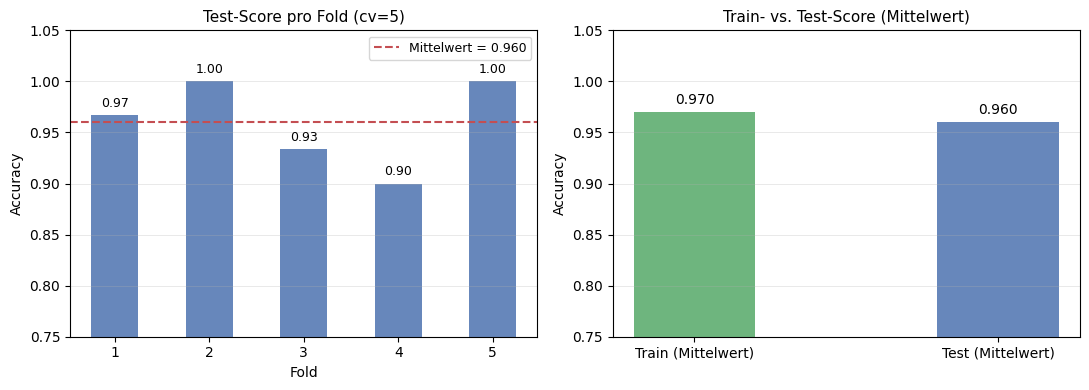

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Linke Grafik: Test-Scores pro Fold
folds = np.arange(1, len(result["test_score"]) + 1)
bars = axes[0].bar(folds, result["test_score"], color="#4C72B0", alpha=0.85, width=0.5)
axes[0].axhline(result["test_score"].mean(), color="#C44E52", linewidth=1.5,
                linestyle="--", label=f"Mittelwert = {result['test_score'].mean():.3f}")
axes[0].set_ylim(0.75, 1.05)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test-Score pro Fold (cv=5)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, axis="y", linewidth=0.4, alpha=0.5)
for bar, val in zip(bars, result["test_score"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Rechte Grafik: Train vs. Test Mittelwert
labels_cv = ["Train (Mittelwert)", "Test (Mittelwert)"]
means = [result["train_score"].mean(), result["test_score"].mean()]
colors_cv = ["#55A868", "#4C72B0"]
b2 = axes[1].bar(labels_cv, means, color=colors_cv, alpha=0.85, width=0.4)
axes[1].set_ylim(0.75, 1.05)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train- vs. Test-Score (Mittelwert)", fontsize=11)
axes[1].grid(True, axis="y", linewidth=0.4, alpha=0.5)
for bar, val in zip(b2, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### Interpretation

Wir verwenden hier als Bewertungsmaß die **Accuracy**, also den Anteil korrekt klassifizierter Beobachtungen.

Wichtig ist:
- Die Scores können sich zwischen den Folds leicht unterscheiden.
- Gerade diese Unterschiede sind didaktisch interessant, weil sie zeigen, dass die Modellbewertung von der Datenaufteilung abhängt.
- Der Mittelwert über mehrere Folds liefert deshalb meist eine robustere Einschätzung als ein einzelner Train/Test-Split.

### Verständnisfragen
1. Warum reicht ein einziger Train/Test-Split manchmal nicht aus?
2. Was ist der Vorteil von Cross-Validation?
3. Warum betrachten wir hier den Mittelwert über mehrere Folds?

### Muster-Antworten


### Mini-Übung
Ändere `cv=5` zu `cv=3` und `cv=10`. Vergleiche die Ergebnisse.

In [ ]:
# Übung 4:
for folds in [3, 5, 10]:
    result = cross_validate(
        pipe_cv,
        X,
        y,
        cv=folds,
        scoring="accuracy"
    )
    print(f"cv={folds}: Mittelwert = {result['test_score'].mean():.4f}")

cv=3: Mittelwert = 0.9667
cv=5: Mittelwert = 0.9600
cv=10: Mittelwert = 0.9600


## 5. Zusammenfassung

Die Kernidee von scikit-learn lässt sich so zusammenfassen:

1. **Daten vorbereiten**
2. **Modell wählen**
3. **mit `fit()` trainieren**
4. **mit `predict()` oder `score()` auswerten**
5. **mit Pipelines und Cross-Validation sauber arbeiten**


### Merksätze
- Ein **Estimator** lernt aus Daten.
- Ein **Transformer** verändert Daten.
- Eine **Pipeline** verbindet beides zu einem sauberen Workflow.
- Gute Ergebnisse auf Trainingsdaten sind **nicht** automatisch gute Ergebnisse auf neuen Daten.
- Nicht jedes Modell profitiert gleichermaßen von Skalierung.